# Netflix Content Analysis: Exploring Trends, Genres and Global Distribution

**Python Data Analysis Portfolio Project**

## Project Objective

The objective of this project is to analyse Netflix's Movies and TV Shows catalogue to identify patterns in content type, growth over time, production countries, content ratings, duration and genres.

The analysis demonstrates practical data cleaning, exploratory data analysis and data visualisation skills using Python, Pandas, Matplotlib and Seaborn.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df = pd.read_csv("netflix_titles.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 1. Load the Dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## 2. Data Cleaning

### 2.1 Check for missing values

In [4]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nPercentage missing:")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing values per column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Percentage missing:
show_id          0.00
type             0.00
title            0.00
director        29.91
cast             9.37
country          9.44
date_added       0.11
release_year     0.00
rating           0.05
duration         0.03
listed_in        0.00
description      0.00
dtype: float64


### 2.2 Fill missing values in categorical columns
`director`, `cast`, and `country` are all text/categorical columns with a large
number of missing values (up to ~30% for `director`). There is no numeric
mean/median to use here, and picking a single "most common" value would be
misleading given how many different directors/countries exist. Instead, we
fill these with a clear placeholder value so we don't lose the rows, while
making it obvious the information was not provided by Netflix's data.

In [5]:
df['director'] = df['director'].fillna('Not Specified')
df['cast'] = df['cast'].fillna('Not Specified')
df['country'] = df['country'].fillna('Not Specified')

print(df[['director', 'cast', 'country']].isnull().sum())

director    0
cast        0
country     0
dtype: int64


### 2.3 Fill missing `rating` with the mode
Only 4 rows are missing a `rating`. Since `rating` is categorical and the number if missing values is very small (0.05% of the dataset), the missing values are filled usinf the mode(most frequent rating). This preserves the overall distribution.

In [6]:
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
print(df['rating'].isnull().sum())

0


### 2.4 Drop rows missing `date_added`
Only 10 rows are missing `date_added`, and this field can't be reasonably
guessed or imputed (unlike a numeric column, there's no "average date" that
makes sense here). Since it's a tiny fraction of the dataset, we drop these
rows rather than risk introducing incorrect dates.

In [7]:
df = df.dropna(subset=['date_added'])
print(f"Shape after dropping missing date_added: {df.shape}")

Shape after dropping missing date_added: (8797, 12)


### 2.5 Handle missing duration values:
 Only 3 rows are missing duration,representing 0.03% of the original dataset.Since duration is important for later analysis and there is no reliable value to infer for these records, the rows are removed rather than introducing estimated values.

In [8]:
df = df.dropna(subset=['duration'])

print(f"Missing duration values: {df['duration'].isnull().sum()}")
print(f"Sgape after dropping missing duration: {df.shape}")

Missing duration values: 0
Sgape after dropping missing duration: (8794, 12)


### 2.6 Check for and remove duplicate rows

In [9]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Number of duplicate rows: 0
Shape after removing duplicates: (8794, 12)


### 2.7 Convert `date_added` to datetime and extract `year_added`
`date_added` is currently stored as text (object dtype). Converting it to a
proper datetime lets us extract useful numeric fields like the year a title
was added to Netflix, which is far more useful for analysis than a raw string.

In [10]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year

print(df[['date_added', 'year_added']].head())
print(df['date_added'].dtype)

  date_added  year_added
0 2021-09-25        2021
1 2021-09-24        2021
2 2021-09-24        2021
3 2021-09-24        2021
4 2021-09-24        2021
datetime64[ns]


### 2.8 Extract numeric values from `duration`
`duration` mixes two different units in one text column — movies are measured
in minutes (e.g. "93 minutes") while TV shows are measured in seasons (e.g.
"4 Seasons"). We extract the numeric portion into its own column so it can
actually be used in calculations, groupby summaries, and correlations.

In [11]:
df['duration_value'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_unit'] = df['duration'].str.extract(r'([A-Za-z]+)')

print(df[['duration', 'duration_value', 'duration_unit']].head(6))

    duration  duration_value duration_unit
0     90 min            90.0           min
1  2 Seasons             2.0       Seasons
2   1 Season             1.0        Season
3   1 Season             1.0        Season
4  2 Seasons             2.0       Seasons
5   1 Season             1.0        Season


### 2.9 Convert `type` to a category dtype
`type` only has two possible values (`Movie` / `TV Show`), so it's a
categorical field rather than free text  converting it saves memory and is
more accurate than a generic `object` dtype.

In [12]:
df['type'] = df['type'].astype('category')
print(df['type'].dtype)

category


### 2.10 Rename columns for clarity

In [13]:
df = df.rename(columns={
    'listed_in': 'genres',
    'type': 'content_type'
})

print(df.columns.tolist())

['show_id', 'content_type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'genres', 'description', 'year_added', 'duration_value', 'duration_unit']


### 2.11 Final shape and confirmation of cleaning

In [14]:
print(f"Final cleaned dataset shape: {df.shape}")

print("\nRemaining missing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Final cleaned dataset shape: (8794, 15)

Remaining missing values:
show_id           0
content_type      0
title             0
director          0
cast              0
country           0
date_added        0
release_year      0
rating            0
duration          0
genres            0
description       0
year_added        0
duration_value    0
duration_unit     0
dtype: int64

Data types:
show_id                   object
content_type            category
title                     object
director                  object
cast                      object
country                   object
date_added        datetime64[ns]
release_year               int64
rating                    object
duration                  object
genres                    object
description               object
year_added                 int32
duration_value           float64
duration_unit             object
dtype: object


## 3. Descriptive Statistics

In [15]:
df[['release_year','year_added','duration_value']].describe().round(2)

,release_year,year_added,duration_value
count,8794.00,8794.00,8794.00
mean,2014.18,2018.87,69.92
std,8.82,1.57,50.80
min,1925.00,2008.00,1.00
25%,2013.00,2018.00,2.00
50%,2017.00,2019.00,88.00
75%,2019.00,2020.00,106.00
max,2021.00,2021.00,312.00


**Commentary on `describe()`:**
- **`release_year`** ranges from as early as the 1920s up to 2021, but the
  25th percentile is already in the 2010s — showing Netflix's catalogue is
  heavily weighted toward recent content rather than older classics.
- **`duration_value`** has a wide spread because it mixes minutes (movies)
  and seasons (TV shows) in the same column — this is exactly why we'll look
  at `content_type` groups separately rather than relying on this single
  combined statistic.
- **`year_added`** clusters tightly around 2019–2020, showing that a large
  share of the catalogue was added to Netflix relatively recently, likely
  reflecting Netflix's rapid content-library expansion in those years.


### 3.1 Movie and TV Show Duration Statistics 



In [16]:
movies = df[df['content_type'] == 'Movie']
tv_shows = df[df['content_type'] == 'TV Show']

print("MOVIE DURATION (MINUTES)")
print(movies['duration_value'].describe().round(2))

print("\nTV SHOW DURATION (SEASONS)")
print(tv_shows['duration_value'].describe().round(2))

MOVIE DURATION (MINUTES)
count    6128.00
mean       99.58
std        28.29
min         3.00
25%        87.00
50%        98.00
75%       114.00
max       312.00
Name: duration_value, dtype: float64

TV SHOW DURATION (SEASONS)
count    2666.00
mean        1.75
std         1.55
min         1.00
25%         1.00
50%         1.00
75%         2.00
max        17.00
Name: duration_value, dtype: float64


### Key Insight:Movies make up the larger portion of the cleaned Netflix catalogue. A typical movie runs for approximately 98–100 minutes, with half of movies falling between 87 and 114 minutes. TV shows are generally short-running: the median is 1 season and 75% have no more than 2 seasons. This suggests that the catalogue contains a substantial number of limited or relatively short-running series.

## 4. GroupBy Analyses

### 4.1 Average duration by content type and unit

In [17]:
df['duration_unit'] = df['duration_unit'].replace({
    'Season': 'Seasons'
})

In [18]:
avg_duration_by_type = (
    df.groupby(['content_type', 'duration_unit'], observed=True)['duration_value']
      .mean()
      .round(2)
)

print(avg_duration_by_type)

content_type  duration_unit
Movie         min              99.58
TV Show       Seasons           1.75
Name: duration_value, dtype: float64


**key insight:** Movies in the cleaned catalogue have an average duration of approximately 99.6 minutes,while TV shows average 1.75 seasons. Because the two content types use different units of measurement,these figures should be interpreted separately.The results also indicate that many TV shows in the datasets have relatively few seasons.

### 4.2 Number of titles added per year

In [19]:
titles_per_year = df.groupby('year_added')['show_id'].count().sort_index()
print(titles_per_year)

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     427
2017    1187
2018    1649
2019    2016
2020    1879
2021    1498
Name: show_id, dtype: int64


**Key insight:** The number of titles added to the catalogue increased substantially from 2016 onwards, rising from 427 titles in 2016 to a peak of 2,016 in 2019. Additions then declined to 1,879 in 2020 and 1,498 in 2021. This shows that catalogue additions accelerated strongly during the late 2010s before slowing in the final two years represented in the dataset.

### 4.3 Most common content rating by content type

In [20]:
rating_by_type = (
    df.groupby(['content_type', 'rating'], observed=True)
      .size()
      .reset_index(name='title_count')
)

most_common_rating = (
    rating_by_type
    .sort_values(['content_type', 'title_count'], ascending=[True, False])
    .groupby('content_type', observed=True)
    .head(1)
)

print(most_common_rating)

   content_type rating  title_count
8         Movie  TV-MA         2064
18      TV Show  TV-MA         1145


**Key Insight:** TV-MA is the most common content rating for both Movies and TV Shows in the cleaned catalogue, accounting for 2,064 Movies and 1,145 TV Shows. This indicates that mature-rated content is strongly represented across both content types in the dataset.

### 4.4 Countries most frequently associated titles 

In [21]:
country_counts = (
    df.loc[df['country'] != 'Not Specified', 'country']
      .str.split(',')
      .explode()
      .str.strip()
      .value_counts()
      .head(10)
)

print(country_counts)

country
United States     3681
India             1046
United Kingdom     805
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


**Key Insight:** The United States is the country most frequently associated with titles in the cleaned dataset, appearing in 3,681 records, followed by India with 1,046 and the United Kingdom with 805. The results show a strong US presence while also highlighting contributions from a broad range of international markets. Titles associated with multiple countries are counted once for each listed country.

## 5. Correlation Analysis 

In [22]:
# Correlation between release year and year added
correlation_matrix = df[['release_year', 'year_added']].corr()

print("Correlation Matrix:")
print(correlation_matrix.round(3))

Correlation Matrix:
              release_year  year_added
release_year         1.000       0.112
year_added           0.112       1.000


**Key Insight:** The correlation between release_year and year_added is 0.112 indicating a weak and positive relationship . Newer titles are therefore only slightly more likely to have been added to the Netflix catalogue in later years. Release year alone therefore does not strongly explain when a title was added to the platform.


**Analysis Note:** duration_value was excluded from the overall correlation analysis because it represents different units for different content types; minutes for Movies and seasons for TV Shows. Combining these values in one correlation calculation could produce a misleading result.

## 6. Outlier Detection (IQR Method)

In [23]:
movies_only = df[df['content_type'] == 'Movie']

Q1 = movies_only['duration_value'].quantile(0.25)
Q3 = movies_only['duration_value'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = movies_only[(movies_only['duration_value'] < lower_bound) | (movies_only['duration_value'] > upper_bound)]
print(f"Number of outlier movies by duration: {len(outliers)}")
print(f"Lower bound: {lower_bound:.1f} min, Upper bound: {upper_bound:.1f} min")
print(outliers[['title', 'duration_value']].sort_values('duration_value', ascending=False).head(10))

Number of outlier movies by duration: 450
Lower bound: 46.5 min, Upper bound: 154.5 min
                            title  duration_value
4253   Black Mirror: Bandersnatch           312.0
717   Headspace: Unwind Your Mind           273.0
2491       The School of Mischief           253.0
2487               No Longer kids           237.0
2484           Lock Your Girls In           233.0
2488              Raya and Sakina           230.0
166   Once Upon a Time in America           229.0
7932                       Sangam           228.0
1019                       Lagaan           224.0
4573                 Jodhaa Akbar           214.0


**Decision on outlers:** The IQR method identified 450 movies outside the expected duration range of 46.5–154.5 minutes. These observations will not be removed automatically because unusually short films and very long films can represent legitimate Netflix content rather than data-entry errors. They will therefore be retained for analysis, while the median may be preferred over the mean when describing typical movie duration because it is less sensitive to extreme values.

### 7. Data Visualisation

This section visualises the key patterns identified during the exploratory analysis and makes the main findings easier to interpret.

In [24]:
content_counts= df['content_type'].value_counts()
content_counts

content_type
Movie      6128
TV Show    2666
Name: count, dtype: int64

## 7.1 Distribution of Movies and TV Shows

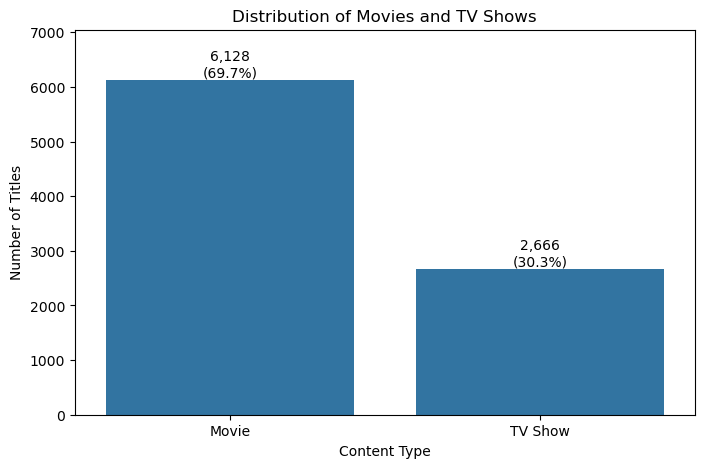

In [25]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=content_counts.index,
    y=content_counts.values
)

plt.title('Distribution of Movies and TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

total = content_counts.sum()

for i, value in enumerate(content_counts.values):
    percentage = value / total * 100
    ax.text(
        i,
        value,
        f'{value:,}\n({percentage:.1f}%)',
        ha='center',
        va='bottom'
    )

plt.ylim(0, content_counts.max() * 1.15)
plt.show()

***Key Insight:** Movies account for approximately 69.7% of the cleaned Netflix catalogue (6,128 titles), compared with 30.3% for TV Shows (2,666 titles). This shows that the catalogue is substantially more heavily weighted toward movies than TV series.

### 7.2 Titles Added per Year

In [26]:
titles_per_year = df.groupby('year_added')['show_id'].count()

print(titles_per_year)

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     427
2017    1187
2018    1649
2019    2016
2020    1879
2021    1498
Name: show_id, dtype: int64


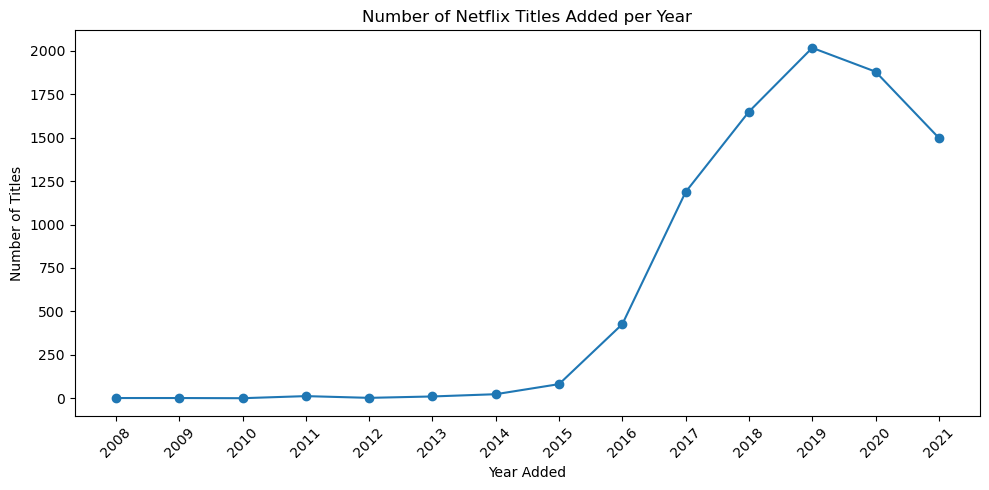

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(
    titles_per_year.index,
    titles_per_year.values,
    marker='o'
)

plt.title('Number of Netflix Titles Added per Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.xticks(titles_per_year.index, rotation=45)
plt.tight_layout()

plt.show()

**Key Insight:** Netflix catalogue additions increased sharply from 2015 onwards, rising from 82 titles in 2015 to a peak of 2,016 in 2019. Additions then declined to 1,879 in 2020 and 1,498 in 2021, indicating that the strongest period of catalogue expansion in this dataset occurred between 2016 and 2019.

### 7.3. Top 10 Countries Producing Netflix Content

In [28]:
country_counts = (
    df.loc[df['country'] != 'Not Specified', 'country']
      .str.split(',')
      .explode()
      .str.strip()
      .value_counts()
      .head(10)
)

print(country_counts)

country
United States     3681
India             1046
United Kingdom     805
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


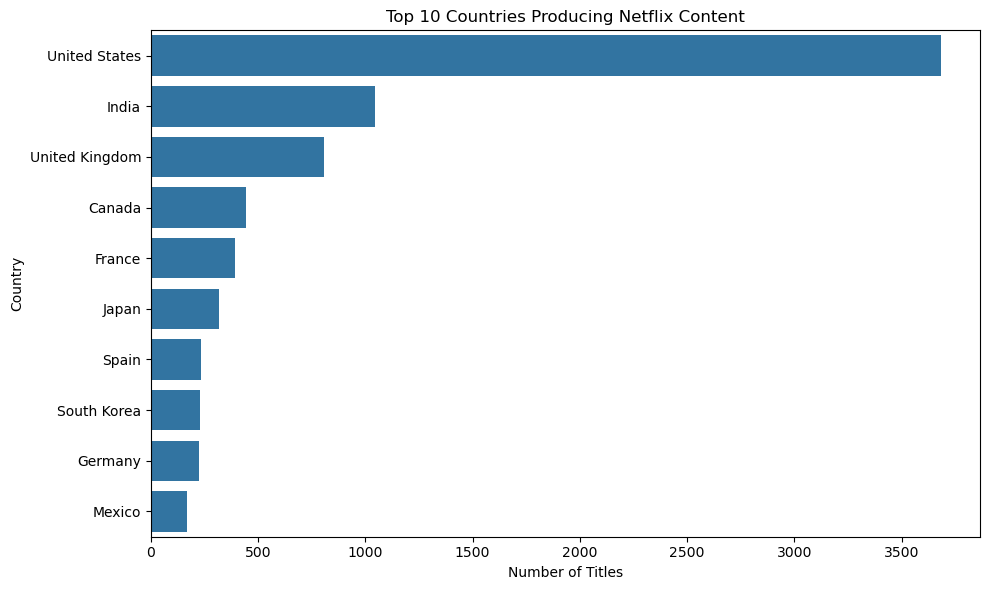

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()

plt.show()

**Key Insight:** The United States is by far the most frequently represented production country in the Netflix catalogue, with 3,681 title associations, followed by India (1,046) and the United Kingdom (805). The large gap between the United States and other countries suggests that the catalogue is strongly concentrated around a small number of major content-producing markets, despite having international representation.

### 7.4. Content Ratings by content type

In [30]:
rating_counts = (
    df.groupby(['content_type', 'rating'], observed=True)
      .size()
      .reset_index(name='title_count')
)

top_ratings = (
    rating_counts
      .sort_values('title_count', ascending=False)
      .groupby('content_type', observed=True)
      .head(5)
)

print(top_ratings)

   content_type rating  title_count
8         Movie  TV-MA         2064
6         Movie  TV-14         1427
18      TV Show  TV-MA         1145
5         Movie      R          797
16      TV Show  TV-14          730
9         Movie  TV-PG          540
4         Movie  PG-13          490
19      TV Show  TV-PG          321
21      TV Show  TV-Y7          194
20      TV Show   TV-Y          175


### 7.4. Chart

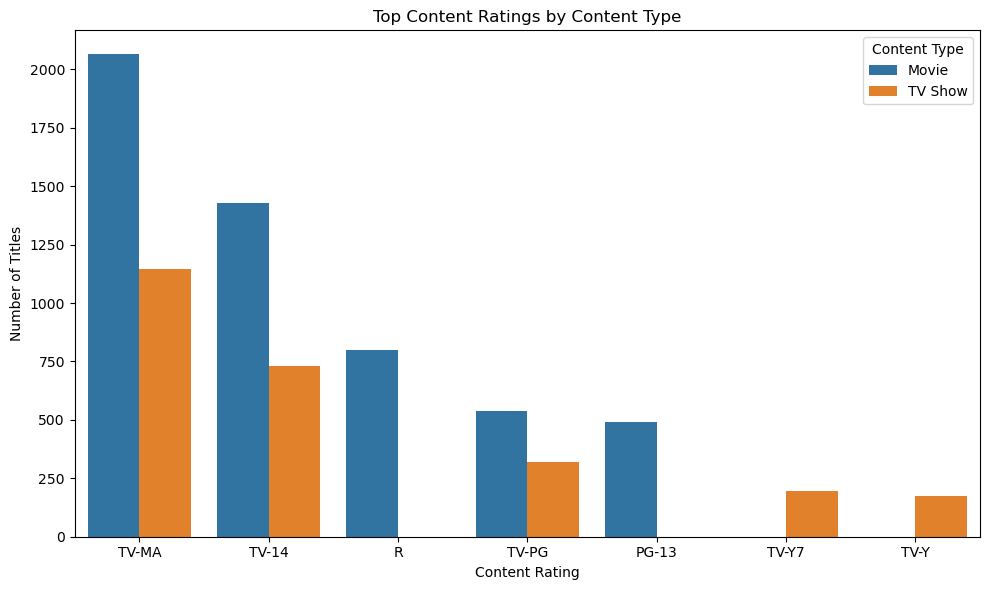

In [31]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_ratings,
    x='rating',
    y='title_count',
    hue='content_type'
)

plt.title('Top Content Ratings by Content Type')
plt.xlabel('Content Rating')
plt.ylabel('Number of Titles')
plt.legend(title='Content Type')
plt.tight_layout()

plt.show()

***Key Insight*** V-MA is the most common content rating for both Movies and TV Shows, with 2,064 movies and 1,145 TV shows. TV-14 is the second most common rating for both content types. Movies also have a strong presence of R and PG-13 rated content, while TV Shows include more youth-oriented ratings such as TV-Y7 and TV-Y. Overall, the catalogue appears to be weighted more heavily toward mature and teenage audiences.

### 7.5 Distribution of Movie Distribution 

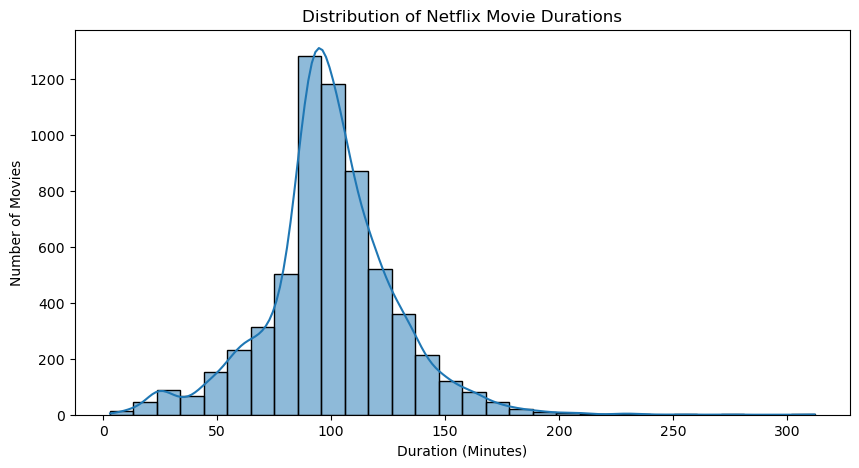

In [32]:
movie_data = df[df['content_type'] == 'Movie']

plt.figure(figsize=(10, 5))

sns.histplot(
    data=movie_data,
    x='duration_value',
    bins=30,
    kde=True
)

plt.title('Distribution of Netflix Movie Durations')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')

plt.show()

***Key Insight*** Netflix movie durations are concentrated around 90–110 minutes, with the highest frequency occurring close to 90–100 minutes. The distribution is right-skewed, with a small number of very long movies extending beyond 200 minutes. These extreme durations are consistent with the outliers identified earlier and were retained because they may represent legitimate films rather than data errors.

In [41]:
genre_data = df[['content_type', 'genres']].copy()

genre_data['genres'] = genre_data['genres'].str.split(',')

# Convert each genre into its own row
genre_data = genre_data.explode('genres')

genre_data['genres'] = genre_data['genres'].str.strip()

genre_counts = (
    genre_data
    .groupby(['content_type', 'genres'], observed=True)
    .size()
    .reset_index(name='title_count')
)

top_genres = (
    genre_data['genres']
    .value_counts()
    .head(10)
    .index
)

plot_data = genre_counts[
    genre_counts['genres'].isin(top_genres)
]

print(plot_data.sort_values('title_count', ascending=False))

   content_type                    genres  title_count
11        Movie      International Movies         2752
7         Movie                    Dramas         2427
4         Movie                  Comedies         1674
25      TV Show    International TV Shows         1350
6         Movie             Documentaries          869
0         Movie        Action & Adventure          859
35      TV Show                 TV Dramas          762
10        Movie        Independent Movies          756
2         Movie  Children & Family Movies          641
15        Movie           Romantic Movies          616


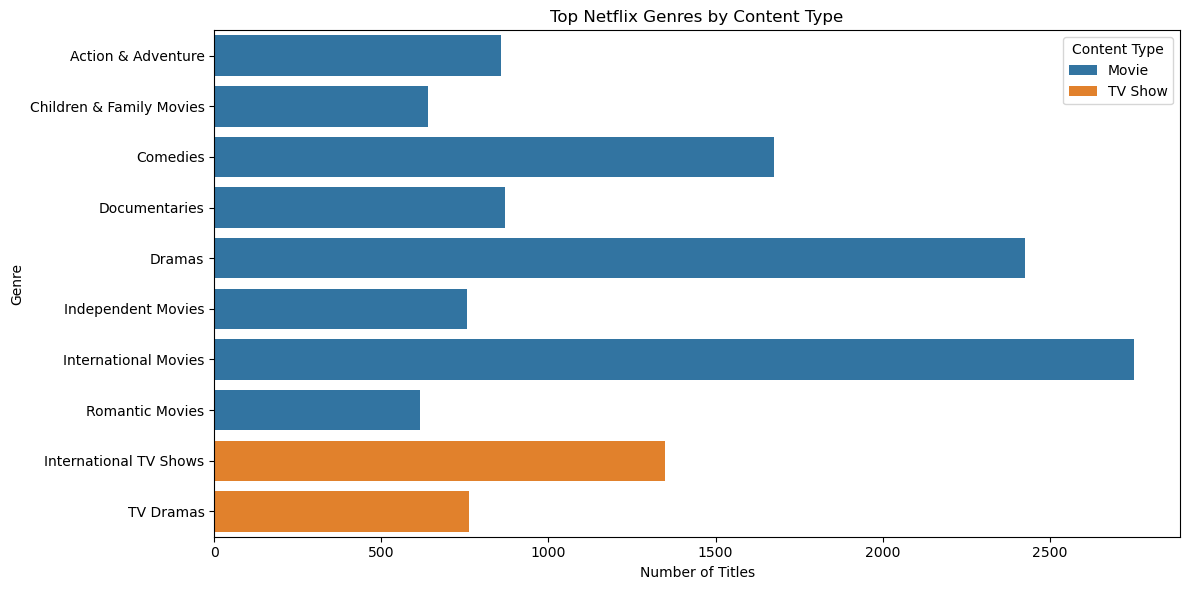

In [42]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_data,
    x='title_count',
    y='genres',
    hue='content_type'
)

plt.title('Top Netflix Genres by Content Type')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.legend(title='Content Type')

plt.tight_layout()
plt.show()

**Key Insight:** Netflix's most common genres are heavily dominated by movie content, with International Movies, Dramas, and Comedies among the largest categories. TV content is more concentrated in International TV Shows and TV Dramas. This suggests that Netflix's catalogue offers considerably greater genre volume through movies, while its TV catalogue is smaller and more concentrated in a few major categories.

## 7.7 Final Business Insights and Recommendation

### Final Business Insights

- Movies make up the majority of the cleaned Netflix catalogue, accounting for approximately 69.7% of titles.
- Catalogue additions increased sharply after 2015 and peaked in 2019, showing a period of rapid expansion.
- The United States is the most heavily represented production country, followed by India and the United Kingdom.
- TV-MA is the most common content rating for both Movies and TV Shows, suggesting a strong focus on mature audiences.
- Movie durations are concentrated around 90–110 minutes, with a small number of very short and very long titles forming the tails of the distribution.
- Genre analysis shows that International Movies, Dramas and Comedies are among the strongest movie categories, while TV content is more concentrated around International TV Shows and TV Dramas.

### Business Recommendation

Netflix could use these findings to diversify its catalogue further by increasing investment in underrepresented countries, genres and audience segments. The current catalogue is heavily concentrated around movies, mature-rated content and a relatively small number of major production markets. Expanding family-oriented, regional and internationally diverse content could help broaden audience reach while reducing dependence on the catalogue's most dominant categories.

## 8. Summary

**Dataset used:** Netflix Movies and TV Shows (`netflix_titles.csv`) 7,787
titles across 12 original columns, covering both movies and TV shows
available on Netflix, with details including cast, country, date added,
release year, content rating, duration, and genre.

**What I cleaned, and why:**
- Filled missing `director`, `cast`, and `country` values with `"Not Specified"`,
  since these are categorical text fields where no single "average" value
  makes sense, and dropping ~30% of rows (for `director`) would have lost too
  much data.
- Filled the 7 missing `rating` values with the column's mode, since this was
  a very small number of affected rows.
- Dropped the 10 rows missing `date_added`, since there's no reasonable way
  to estimate a missing date and the row count affected was negligible.
- Converted `date_added` to a proper datetime and extracted `year_added` as a
  usable numeric field for trend analysis.
- Split the mixed-unit `duration` text column into a numeric `duration_value`
  plus a `duration_unit` label, since minutes (movies) and seasons (TV shows)
  can't be meaningfully compared as a single number without separating them.
- Converted `type` (renamed to `content_type`) to a category dtype, since it
  only has two possible values.
- Renamed `listed_in` to `genres` and `type` to `content_type` for clarity.

**3 key findings:**
1. Netflix's catalogue is dominated by **Movies over TV Shows** (roughly 69%
   vs 31%), and the average TV show only runs a couple of seasons most
   content is designed for one-off or short-run viewing rather than
   long-running series.
2. Content acquisition **accelerated sharply after 2015**, peaking around
   2019, reflecting Netflix's aggressive global content expansion during that
   period.
3. **TV-MA is the single most common content rating** across both movies and
   TV shows, and the **United States and India are by far the largest content
   sources**, showing the catalogue skews toward mature audiences and is
   concentrated in a small number of major producing countries.

**Recommendation:** Given how concentrated Netflix's catalogue is around the
US and India, and how strongly it skews toward mature (`TV-MA`) content,
Netflix could grow its audience reach by investing more deliberately in
content from underrepresented countries and in family-friendly (lower-rating)
title this would help diversify the catalogue and could open up
underserved audience segments rather than continuing to concentrate
investment in already well-covered markets and rating categories.
